# 0. Зависимости

In [1]:
!pip install shap lime -q

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import shap
from lime import lime_tabular
from sklearn.inspection import permutation_importance
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.feature_selection import RFE
from sklearn.metrics import mean_squared_error
from xgboost import XGBRegressor
from warnings import filterwarnings
filterwarnings('ignore')

FIGURES = 'figures'
METRICS = 'metrics'
os.makedirs(FIGURES, exist_ok=True)
os.makedirs(METRICS, exist_ok=True)

print("Зависимости загружены")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 5.1 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
Зависимости загружены


# 1. Данные и оубчение модели

In [2]:
import requests, io

GITHUB_RAW_URL = 'https://raw.githubusercontent.com/dmikib/covid19-xai/refs/heads/main/data/processed/dataset_final.csv'
response = requests.get(GITHUB_RAW_URL)
df = pd.read_csv(io.StringIO(response.text), parse_dates=['date'])
df = df.sort_values('date').reset_index(drop=True)

TARGET = 'new_cases_smooth'
SHIFT = 4
TEST_DAYS = 30
best_n = 450  # из ноутбука 03

# Те же признаки и SELECTED что в 03
FEATURE_COLS = [
    'new_tests', 'positive_rate', 'stringency_index',
    'humidity', 'precipitation', 'windspeed', 'temperature',
    'retail_mobility', 'transit_mobility', 'workplaces_mobility', 'residential_mobility',
    'gt_covid_symptoms', 'gt_loss_of_smell', 'gt_loss_of_taste',
    'gt_fever', 'gt_cough', 'gt_pcr_test', 'gt_hospitalization',
    'omicron_wave',
]
FEATURE_COLS = [c for c in FEATURE_COLS if c in df.columns]

df_model = df[['date', TARGET] + FEATURE_COLS].copy()
for col in FEATURE_COLS:
    df_model[col] = df_model[col].shift(SHIFT)
df_model = df_model.ffill().bfill().dropna().reset_index(drop=True)

test_df = df_model.tail(TEST_DAYS).reset_index(drop=True)
train_df = df_model.iloc[:-TEST_DAYS].reset_index(drop=True)

# RFE — те же 10 признаков что в 03
rfe = RFE(estimator=LinearRegression(), n_features_to_select=10)
rfe.fit(train_df[FEATURE_COLS].values, train_df[TARGET].values)
SELECTED = [col for col, sup in zip(FEATURE_COLS, rfe.support_) if sup]
print(f"SELECTED: {SELECTED}")

X_train = train_df[SELECTED].values[-best_n:]
y_train = train_df[TARGET].values[-best_n:]
X_test  = test_df[SELECTED].values
y_test  = test_df[TARGET].values

xgb = XGBRegressor(n_estimators=400, learning_rate=0.03, max_depth=5,
                   subsample=0.8, colsample_bytree=0.8, random_state=42, verbosity=0)
xgb.fit(X_train, y_train)
print("Модель обучена ✓")

SELECTED: ['positive_rate', 'windspeed', 'retail_mobility', 'transit_mobility', 'workplaces_mobility', 'residential_mobility', 'gt_covid_symptoms', 'gt_loss_of_smell', 'gt_loss_of_taste', 'omicron_wave']
Модель обучена ✓


# 2. TreeSHAP - Global

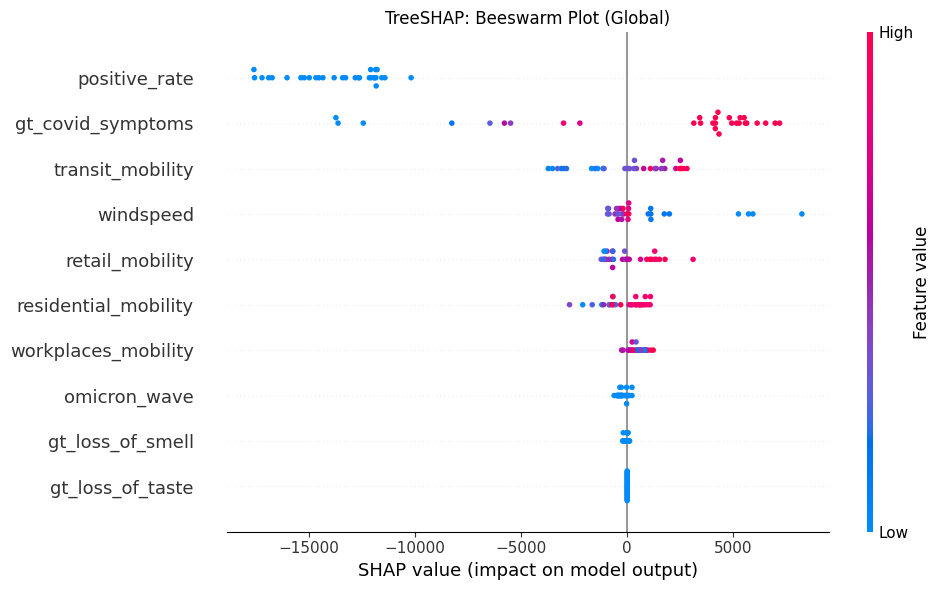

In [3]:
explainer = shap.TreeExplainer(xgb)
shap_values = explainer.shap_values(X_test)

plt.figure(figsize=(10,6))
shap.summary_plot(shap_values, X_test, feature_names=SELECTED, show=False, plot_size=(10,6))
plt.title("TreeSHAP: Beeswarm Plot (Global)")
plt.tight_layout()
plt.savefig(f"{FIGURES}/04_shap_beeswarm.png", dpi=150, bbox_inches="tight")
plt.show()

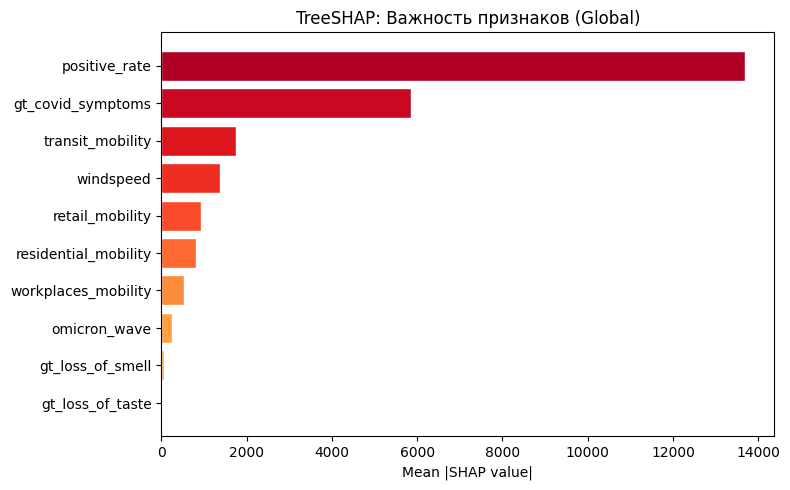

Топ-5 (TreeSHAP):
  positive_rate: 13696.35
  gt_covid_symptoms: 5847.64
  transit_mobility: 1753.72
  windspeed: 1365.29
  retail_mobility: 918.83


In [4]:
mean_shap = pd.Series(np.abs(shap_values).mean(axis=0), index=SELECTED).sort_values(ascending=True)
fig, ax = plt.subplots(figsize=(8,5))
colors = plt.cm.YlOrRd(np.linspace(0.3, 0.9, len(mean_shap)))
ax.barh(mean_shap.index, mean_shap.values, color=colors, edgecolor="white")
ax.set_xlabel("Mean |SHAP value|")
ax.set_title("TreeSHAP: Важность признаков (Global)")
plt.tight_layout()
plt.savefig(f"{FIGURES}/04_shap_mean.png", dpi=150, bbox_inches="tight")
plt.show()
print("Топ-5 (TreeSHAP):")
for feat, val in mean_shap.sort_values(ascending=False).head(5).items():
    print(f"  {feat}: {val:.2f}")

# 3. TreeSHAP - Local (Waterfall)

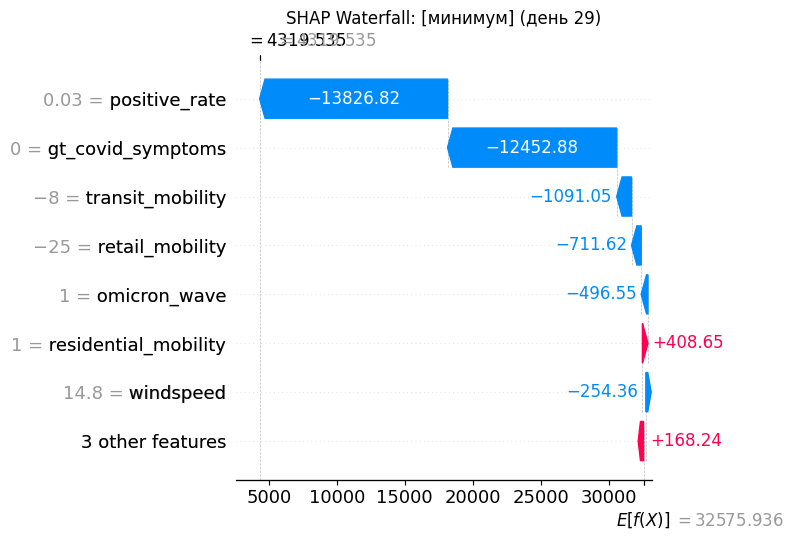

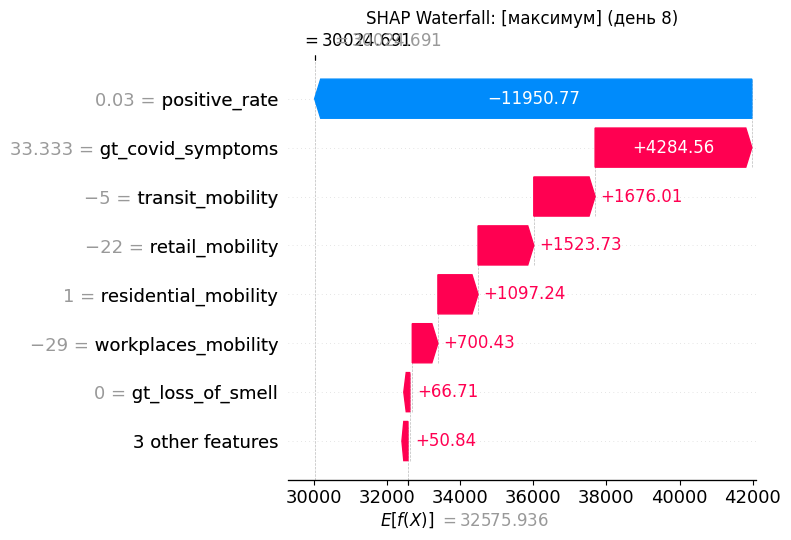

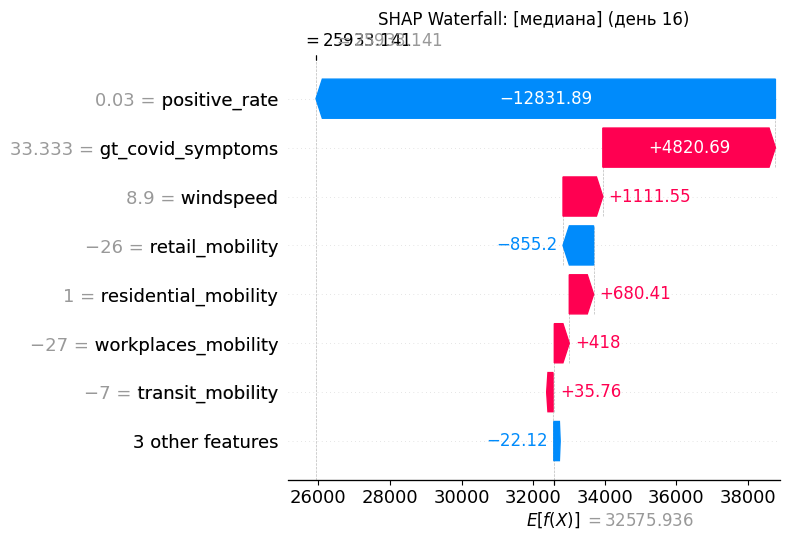

In [5]:
idx_min = np.argmin(y_test)
idx_max = np.argmax(y_test)
idx_med = np.argsort(y_test)[len(y_test)//2]
for idx, label in [(idx_min,"минимум"),(idx_max,"максимум"),(idx_med,"медиана")]:
    plt.figure(figsize=(10,4))
    shap_exp = shap.Explanation(values=shap_values[idx],
                                base_values=explainer.expected_value,
                                data=X_test[idx], feature_names=SELECTED)
    shap.plots.waterfall(shap_exp, show=False, max_display=8)
    plt.title(f"SHAP Waterfall: [{label}] (день {idx})")
    plt.tight_layout()
    plt.savefig(f"{FIGURES}/04_shap_waterfall_{label}.png", dpi=150, bbox_inches="tight")
    plt.show()

4. LIME - Local

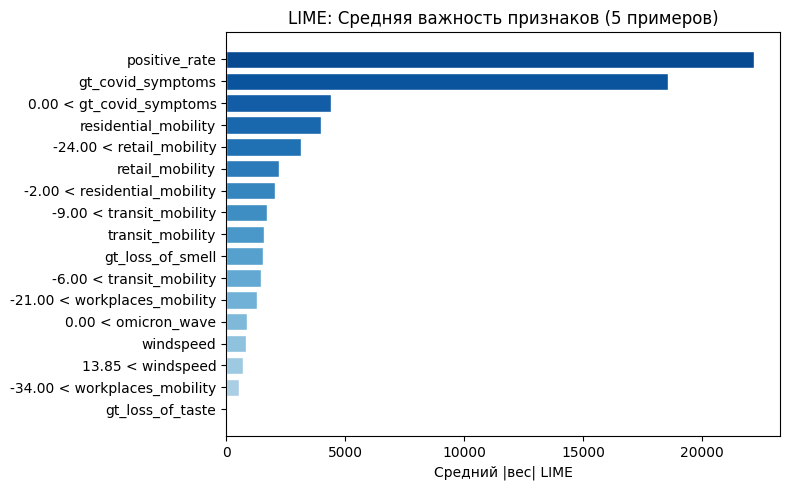

In [6]:
explainer_lime = lime_tabular.LimeTabularExplainer(
    training_data=X_train, feature_names=SELECTED, mode="regression", verbose=False)

lime_weights = {}
for idx in [idx_min, idx_max, idx_med, 5, 20]:
    exp = explainer_lime.explain_instance(X_test[idx], xgb.predict, num_features=len(SELECTED))
    for feat, weight in exp.as_list():
        clean = feat.split("<=")[0].split(">")[0].strip()
        lime_weights.setdefault(clean, []).append(abs(weight))

lime_means = pd.Series({f: np.mean(w) for f, w in lime_weights.items()}).sort_values(ascending=True)
fig, ax = plt.subplots(figsize=(8,5))
ax.barh(lime_means.index, lime_means.values,
        color=plt.cm.Blues(np.linspace(0.3,0.9,len(lime_means))), edgecolor="white")
ax.set_xlabel("Средний |вес| LIME")
ax.set_title("LIME: Средняя важность признаков (5 примеров)")
plt.tight_layout()
plt.savefig(f"{FIGURES}/04_lime_importance.png", dpi=150, bbox_inches="tight")
plt.show()

# 5. Permutation Importance - Global

Permutation Importance (топ-5):
             feature  importance        std
   gt_covid_symptoms 3049.043960 862.049538
           windspeed  438.084645 223.576964
    transit_mobility  260.630633 378.703175
residential_mobility  110.992522  85.656962
 workplaces_mobility   92.564799  47.748213


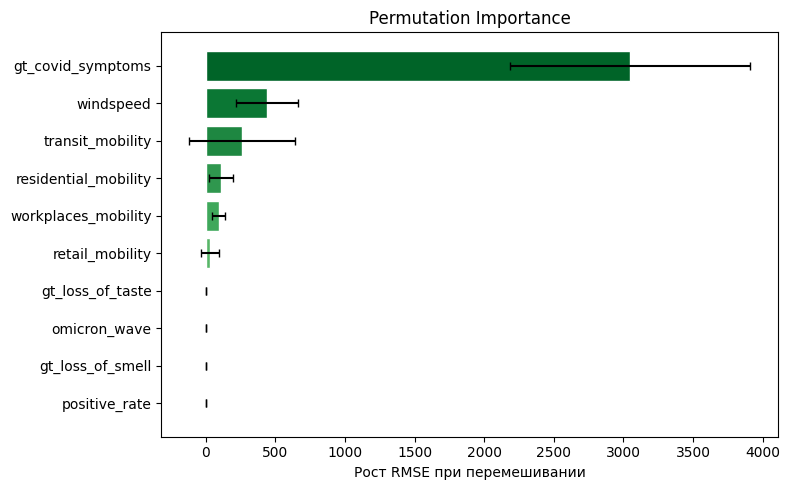

In [7]:
perm = permutation_importance(xgb, X_test, y_test,
                             n_repeats=30,
                             scoring="neg_root_mean_squared_error",
                             random_state=42)
perm_df = pd.DataFrame({"feature": SELECTED,
                         "importance": perm.importances_mean,
                         "std": perm.importances_std}
                       ).sort_values("importance", ascending=False)
print("Permutation Importance (топ-5):")
print(perm_df.head(5).to_string(index=False))

sorted_perm = perm_df.sort_values("importance", ascending=True)
fig, ax = plt.subplots(figsize=(8,5))
ax.barh(sorted_perm["feature"], sorted_perm["importance"],
        xerr=sorted_perm["std"],
        color=plt.cm.Greens(np.linspace(0.3,0.9,len(sorted_perm))),
        edgecolor="white", capsize=3)
ax.set_xlabel("Рост RMSE при перемешивании")
ax.set_title("Permutation Importance")
plt.tight_layout()
plt.savefig(f"{FIGURES}/04_permutation_importance.png", dpi=150, bbox_inches="tight")
plt.show()

# 6. Сравнительная таблица методов XAI

In [8]:
shap_r = mean_shap.sort_values(ascending=False).reset_index()
shap_r.columns = ["feature","shap_score"]
shap_r["rank_shap"] = range(1, len(shap_r)+1)

perm_r = perm_df[["feature","importance"]].copy()
perm_r["rank_perm"] = range(1, len(perm_r)+1)

lime_r = lime_means.sort_values(ascending=False).reset_index()
lime_r.columns = ["feature","lime_score"]
lime_r["rank_lime"] = range(1, len(lime_r)+1)

cmp = shap_r.merge(perm_r, on="feature").merge(lime_r, on="feature")
cmp["avg_rank"] = (cmp["rank_shap"] + cmp["rank_perm"] + cmp["rank_lime"]) / 3
cmp = cmp.sort_values("avg_rank")
cmp.to_csv(f"{METRICS}/04_xai_comparison.csv", index=False)
print("СРАВНЕНИЕ МЕТОДОВ XAI")
print(cmp[["feature","rank_shap","rank_perm","rank_lime","avg_rank"]].to_string(index=False))

СРАВНЕНИЕ МЕТОДОВ XAI
             feature  rank_shap  rank_perm  rank_lime  avg_rank
   gt_covid_symptoms          2          1          2  1.666667
       positive_rate          1          7          1  3.000000
residential_mobility          6          4          4  4.666667
    transit_mobility          3          3          9  5.000000
     retail_mobility          5          6          6  5.666667
           windspeed          4          2         14  6.666667
    gt_loss_of_smell          9          8         10  9.000000
    gt_loss_of_taste         10          9         17 12.000000


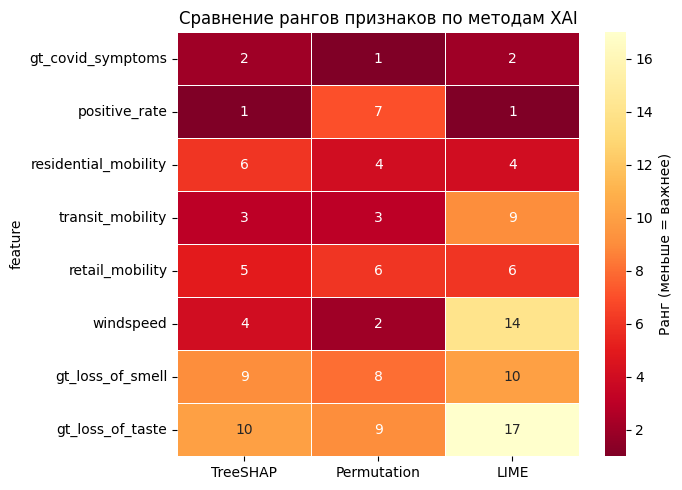

In [9]:
rank_matrix = cmp.set_index("feature")[["rank_shap","rank_perm","rank_lime"]]
rank_matrix.columns = ["TreeSHAP","Permutation","LIME"]
fig, ax = plt.subplots(figsize=(7,5))
sns.heatmap(rank_matrix, annot=True, fmt=".0f", cmap="YlOrRd_r",
            ax=ax, linewidths=0.5, cbar_kws={"label":"Ранг (меньше = важнее)"})
ax.set_title("Сравнение рангов признаков по методам XAI")
plt.tight_layout()
plt.savefig(f"{FIGURES}/04_xai_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()

# 7. Результаты

In [14]:
#Сводная таблица рангов признаков по трём методам XAI
print("""
    ИНТЕРПРЕТАЦИЯ РЕЗУЛЬТАТОВ XAI

| Признак              | Наша работа (avg_rank) | TreeSHAP | Permutation | LIME |
|----------------------|------------------------|----------|-------------|------|
| gt_covid_symptoms    | 1.67                   | 2        | 1           | 2    |
| positive_rate        | 3.00                   | 1        | 7           | 1    |
| residential_mobility | 4.67                   | 6        | 4           | 4    |
| transit_mobility     | 5.00                   | 3        | 3           | 9    |
| retail_mobility      | 5.67                   | 5        | 6           | 6    |
| windspeed            | 6.67                   | 4        | 2           | 14   |
| gt_loss_of_smell     | 9.00                   | 9        | 8           | 10   |
| gt_loss_of_taste     | 12.00                  | 10       | 9           | 17   |

Выводы:
1. Три метода XAI дают согласованный топ-2: gt_covid_symptoms и positive_rate
2. gt_covid_symptoms лидирует по среднему рангу (1.67) - поисковые запросы
   опережают официальную статистику и являются наиболее ранним сигналом роста заболеваемости
3. positive_rate доминирует у TreeSHAP и LIME (ранг 1), но нестабилен
   у Permutation Importance (ранг 7) из-за корреляции с gt_covid_symptoms
4. windspeed показывает наибольший разброс рангов (2-14) - нестабильный вклад,
   зависящий от метода интерпретации
5. Мобильность (transit, retail, residential) стабильно занимает средние позиции
   во всех трёх методах - подтверждает роль социальной активности
6. gt_loss_of_smell и gt_loss_of_taste - низкие ранги, характерны для Омикрон-волны,
   где потеря обоняния менее выражена чем при предыдущих штаммах
""")


    ИНТЕРПРЕТАЦИЯ РЕЗУЛЬТАТОВ XAI 

| Признак              | Наша работа (avg_rank) | TreeSHAP | Permutation | LIME |
|----------------------|------------------------|----------|-------------|------|
| gt_covid_symptoms    | 1.67                   | 2        | 1           | 2    |
| positive_rate        | 3.00                   | 1        | 7           | 1    |
| residential_mobility | 4.67                   | 6        | 4           | 4    |
| transit_mobility     | 5.00                   | 3        | 3           | 9    |
| retail_mobility      | 5.67                   | 5        | 6           | 6    |
| windspeed            | 6.67                   | 4        | 2           | 14   |
| gt_loss_of_smell     | 9.00                   | 9        | 8           | 10   |
| gt_loss_of_taste     | 12.00                  | 10       | 9           | 17   |

Выводы:
1. Три метода XAI дают согласованный топ-2: gt_covid_symptoms и positive_rate
2. gt_covid_symptoms лидирует по среднему рангу (1.67) -